In [8]:
import pandas as pd
import sys
import os

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../'))
import Function.path as path

In [4]:
file_path = f'{path.data_path}/ribo8s002_20260804_0001DLC_resnet50_stickerNoseScopeAug4shuffle1_100000.h5'
df = pd.read_hdf(file_path)
print(df.shape)
print(df.columns)

(72771, 21)
MultiIndex([('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', ...),
            ('DLC_resnet50_stickerNoseScopeAug4shuffle1_100000', 

In [5]:
df

scorer    DLC_resnet50_stickerNoseScopeAug4shuffle1_100000              \
bodyparts                                             nose               
coords                                                   x           y   
0                                               320.008240  503.786133   
1                                               318.908661  508.846130   
2                                               323.020813  517.799133   
3                                               297.407593  404.782318   
4                                               315.077271  520.235718   
...                                                    ...         ...   
72766                                           469.619537  894.645691   
72767                                           487.762787  890.478333   
72768                                           505.183197  890.373962   
72769                                           526.909790  890.972351   
72770                                           548.047058  891.820618   

scorer                                                               \
bodyparts                leftEar                           rightEar   
coords    likelihood           x           y likelihood           x   
0           0.146103  341.172150  466.960693   0.997771  301.066833   
1           0.186703  340.111450  475.792206   0.996193  302.441315   
2           0.313488  338.471680  481.178162   0.998635  300.568909   
3           0.346019  337.979218  483.345428   0.998820  298.822571   
4           0.355869  336.103394  484.011932   0.998105  297.329651   
...              ...         ...         ...        ...         ...   
72766       0.987079  428.783264  872.999756   0.990552  429.642731   
72767       0.965817  447.658478  871.495239   0.993319  449.801849   
72768       0.988505  466.732910  870.407593   0.995669  468.983368   
72769       0.989442  489.932617  868.928528   0.993104  490.644745   
72770       0.993844  510.050049  871.137024   0.993719  508.863892   

scorer                                        ...                         \
bodyparts                              scope  ...                   neck   
coords              y likelihood           x  ... likelihood           x   
0          475.244629   0.995325  329.799408  ...   0.994462  321.969116   
1          481.648651   0.994034  328.885437  ...   0.998926  321.498383   
2          484.436646   0.997645  326.770386  ...   0.997581  320.061066   
3          488.376984   0.996769  325.603760  ...   0.998630  319.266876   
4          490.444061   0.994016  324.839661  ...   0.999027  317.027527   
...               ...        ...         ...  ...        ...         ...   
72766      913.053040   0.997680  431.378143  ...   0.997910  427.114044   
72767      910.644409   0.997577  451.023987  ...   0.998829  443.411804   
72768      911.914673   0.999009  470.402222  ...   0.998977  464.599518   
72769      910.747192   0.997099  493.319122  ...   0.998388  488.356140   
72770      911.177612   0.995572  512.072327  ...   0.997760  506.719177   

scorer                                                               \
bodyparts                               back                          
coords              y likelihood           x           y likelihood   
0          473.631439   0.998204  313.845703  433.926178   0.985628   
1          479.540985   0.999202  313.792603  439.305634   0.988308   
2          485.123840   0.999218  313.266968  443.288971   0.979890   
3          488.349335   0.996711  313.001038  451.528259   0.990453   
4          489.939270   0.994569  310.978851  454.196594   0.995606   
...               ...        ...         ...         ...        ...   
72766      898.112671   0.071005  402.158600  900.812317   0.999555   
72767      898.445984   0.044609  422.845978  899.989258   0.998955   
72768      885.844177   0.017240  441.580627  900.255249   0.997532   
72769      896.416077   0.043768  464.959808  898.5

In [6]:
bodypart_data = {
    bodypart: (
        df.xs(bodypart, level="bodyparts", axis=1)
          .droplevel("scorer", axis=1)
          .loc[:, ["x", "y", "likelihood"]]
          .copy()
    )
    for bodypart in df.columns.get_level_values("bodyparts").unique()
}

print(bodypart_data.keys())

dict_keys(['nose', 'leftEar', 'rightEar', 'scope', 'neck', 'back', 'tailBase'])


In [ ]:
class Kinematics:
    def __init__(self, data):
        self.manual_parameters = self.Get_Manual_Parameters()
        self.parameters = {}
        self.filterRes = None
        self.smoothRes = None
        self.data = data
        
    def Run(self):
        self.Infer_Parameters()
        self.Inference() 
        
    def Get_Manual_Parameters(self):
        dt = 0.1
        pos_x0, pos_y0 = 0, 0
        vel_x0, vel_y0 = 0.0, 0.0
        acc_x0, acc_y0 = 0.0, 0.0

        # Manual Parameters
        sigma_a = 20
        sqrt_diag_V0_value = 1e-3

        m0 = np.array([pos_x0, vel_x0, acc_x0, pos_y0, vel_y0, acc_y0], dtype=np.double)
        V0 = np.diag(np.ones(len(m0))*sqrt_diag_V0_value**2)


        B = np.array([[1, dt, dt**2/2, 0, 0, 0],
                    [0, 1, dt, 0, 0, 0],
                    [0, 0, 1, 0, 0, 0],
                    [0, 0, 0, 1, dt, dt**2/2],
                    [0, 0, 0, 0, 1, dt],
                    [0, 0, 0, 0, 0, 1]],
                    dtype=np.double)


        Qe = np.array([[dt**4/4, dt**3/2, dt**2/2, 0, 0, 0],
                    [dt**3/2, dt**2,   dt,      0, 0, 0],
                    [dt**2/2, dt,      1,       0, 0, 0],
                    [0, 0, 0, dt**4/4, dt**3/2, dt**2/2],
                    [0, 0, 0, dt**3/2, dt**2,   dt],
                    [0, 0, 0, dt**2/2, dt,      1]],
                    dtype=np.double)
        Q = sigma_a**2 * Qe

        sigma_x = 1
        sigma_y = 1

        Z = np.array([[1, 0, 0, 0, 0, 0],
                    [0, 0, 0, 1, 0, 0]],
                    dtype=np.double)
        R = np.diag([sigma_x**2, sigma_y**2])
        
        parameters = {'sigma_a': sigma_a,
                    'sigma_x': sigma_x,
                    'sigma_y': sigma_y,
                    'sqrt_diag_V0_value': sqrt_diag_V0_value,
                    'B': B,
                    'Qe': Qe,
                    'm0': m0,
                    'V0': V0,
                    'Z': Z,
                    'R': R}
        return parameters
    
    def Learn_Parameters(self, y, sigma_a, sigma_x, sigma_y, sqrt_diag_V0_value, B, Qe, m0, Z):
        lbfgs_max_iter = 2
        lbfgs_tolerance_grad = 1e-3
        lbfgs_tolerance_change = 1e-3
        lbfgs_lr = 1.0
        lbfgs_n_epochs = 100
        lbfgs_tol = 1e-3
        
        Qe_reg_param_learned = 1e-10
        sqrt_diag_R_torch = torch.DoubleTensor([sigma_x, sigma_y])
        m0_torch = torch.from_numpy(m0.copy())
        sqrt_diag_V0_torch = torch.DoubleTensor([sqrt_diag_V0_value
                                                for i in range(len(m0))])
        if Qe_reg_param_learned is not None:
            Qe_regularized_learned = Qe + Qe_reg_param_learned * np.eye(Qe.shape[0])
        else:
            Qe_regularized_learned = Qe
        y_torch = torch.from_numpy(y.astype(np.double))
        B_torch = torch.from_numpy(B.astype(np.double))
        Qe_regularized_learned_torch = torch.from_numpy(Qe_regularized_learned.astype(np.double))
        Z_torch = torch.from_numpy(Z.astype(np.double))

        vars_to_estimate = {}
        vars_to_estimate["sigma_a"] = True
        vars_to_estimate["sqrt_diag_R"] = True
        vars_to_estimate["R"] = True
        vars_to_estimate["m0"] = True
        vars_to_estimate["sqrt_diag_V0"] = True
        vars_to_estimate["V0"] = True

        optim_res_learned = learning.torch_lbfgs_optimize_SS_tracking_diagV0(
            y=y_torch, B=B_torch, sigma_a0=sigma_a,
            Qe=Qe_regularized_learned_torch, Z=Z_torch, sqrt_diag_R_0=sqrt_diag_R_torch, m0_0=m0_torch,
            sqrt_diag_V0_0=sqrt_diag_V0_torch, max_iter=lbfgs_max_iter, lr=lbfgs_lr,
            vars_to_estimate=vars_to_estimate, tolerance_grad=lbfgs_tolerance_grad,
            tolerance_change=lbfgs_tolerance_change, n_epochs=lbfgs_n_epochs,
            tol=lbfgs_tol)
        
        sigma_a = optim_res_learned["estimates"]["sigma_a"].item()
        sigma_x = optim_res_learned["estimates"]["sqrt_diag_R"].numpy()[0]
        sigma_y = optim_res_learned["estimates"]["sqrt_diag_R"].numpy()[1]
        sqrt_diag_V0_value = optim_res_learned["estimates"]["sqrt_diag_V0"].numpy()
        m0 = optim_res_learned["estimates"]["m0"].numpy()
        V0 = np.diag(sqrt_diag_V0_value**2)
        R = np.diag(optim_res_learned["estimates"]["sqrt_diag_R"].numpy()**2)

        return sigma_a, sigma_x, sigma_y, sqrt_diag_V0_value[0], B, m0, V0, Z, R
    
    def Get_Observations(self):
        mouse_pos = 
        return mouse_pos
    
    def Infer_Parameters(self):
        mouse_pos = self.Get_Observations()
        obs = np.transpose(mouse_pos[["x", "y"]].to_numpy())
        
        params = self.manual_parameters
        sigma_a = params['sigma_a']
        sigma_x = params['sigma_x']
        sigma_y = params['sigma_y']
        sqrt_diag_V0_value = params['sqrt_diag_V0_value']
        B = params['B']
        Qe = params['Qe']
        m0 = params['m0']
        V0 = params['V0']
        Z = params['Z']
        R = params['R']

        sigma_a, sigma_x, sigma_y, sqrt_diag_V0_value, B, m0, V0, Z, R = self.Learn_Parameters(obs, sigma_a, sigma_x, sigma_y, sqrt_diag_V0_value, B, Qe, m0, Z)
        np.savez(f'{path.data_path}/Parameters.npz', sigma_a = sigma_a, sigma_x = sigma_x, sigma_y = sigma_y, sqrt_diag_V0_value = sqrt_diag_V0_value, B = B, Qe = Qe, m0 = m0, V0 = V0, Z = Z, R = R)
        print('Inferring LDS Parameters Completed')
        
        parameters = {'sigma_a': sigma_a,
                    'sigma_x': sigma_x,
                    'sigma_y': sigma_y,
                    'sqrt_diag_V0_value': sqrt_diag_V0_value,
                    'B': B,
                    'Qe': Qe,
                    'm0': m0,
                    'V0': V0,
                    'Z': Z,
                    'R': R}

        self.parameters = parameters
    
    def Inference(self):
        '''try:
            filterRes = np.load(f'../../SocialData/LDS/{self.session.start}_filterRes.npz')
            smoothRes = np.load(f'../../SocialData/LDS/{self.session.start}_smoothRes.npz')
        except FileNotFoundError:'''
        obs = np.transpose(self.data[["x", "y"]].to_numpy())
        
        params = self.parameters
        sigma_a = params['sigma_a']
        B = params['B']
        Qe = params['Qe']
        m0 = params['m0']
        V0 = params['V0']
        Z = params['Z']
        R = params['R']

        Q = (sigma_a**2) * Qe

        # Filtering
        filterRes = inference.filterLDS_SS_withMissingValues_np(
            y=obs, B=B, Q=Q, m0=m0, V0=V0, Z=Z, R=R)
        np.savez_compressed(f'{path.data_path}/filterRes.npz', **filterRes)
            
        # Smoothing
        smoothRes = inference.smoothLDS_SS( 
            B=B, xnn=filterRes["xnn"], Vnn=filterRes["Vnn"],
            xnn1=filterRes["xnn1"], Vnn1=filterRes["Vnn1"], m0=m0, V0=V0)
        np.savez_compressed(f'{path.data_path}/smoothRes.npz', **smoothRes) 
        print('Inference Completed')
            
        self.filterRes = filterRes
        self.smoothRes = smoothRes

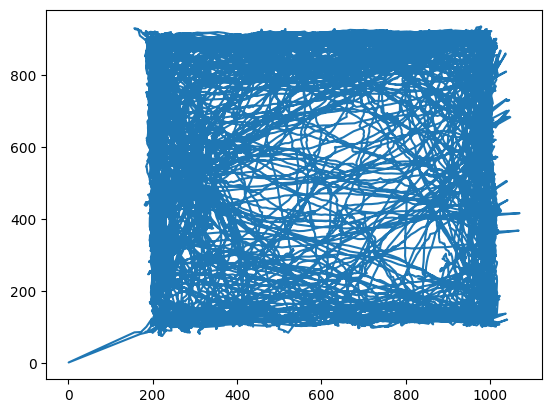

In [10]:
x = bodypart_data['back']['x']
y = bodypart_data['back']['y']

plt.plot(x, y)
plt.show()